In [72]:
import warnings
warnings.filterwarnings('ignore', message = ".*Glyph.*")
warnings.filterwarnings('ignore', message = ".*IProgress not found.*")
import os
import gc, json, random, shutil, subprocess, sys, time
from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib import font_manager
from PIL import Image

plt.rcParams['font.family'] = 'Malgun Gothic'

QUICK = True

BASE = Path.cwd()
ASSETS = BASE / 'assets' / 'assets'
DATA = BASE / 'data' / 'data' / 'knowledge'
WORK = BASE / 'work'
for d in ('models', 'chroma', 'images'):
    (WORK / d).mkdir(parents = True, exist_ok = True)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

IMG_DTYPE = torch.float16 if DEVICE == 'cuda' else torch.float32

installed = {f.name for f in font_manager.fontManager.ttflist}

plt.rcParams['axes.unicode_minus'] = False

In [82]:
def set_seed(seed = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

def free_memory():
    gc.collect()
    if DEVICE == 'cuda':
        torch.cuda.empty_cache()

def show_images(images, titles = None, cols = None, size = 3.2):
    cols = cols or len(images)
    rows = (len(images) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize = (size * cols, size * rows), squeeze = False)
    for ax in axes.ravel(): ax.axis('off')
    for i, img in enumerate(images):
        axes.ravel()[i].imshow(img)
        if titles: axes.ravel()[i].set_title(titles[i], fontsize = 10)
    plt.tight_layout()
    plt.show()
set_seed(42)
print(DEVICE, QUICK)
print(BASE)

cuda True
c:\Users\use\Documents\KDT17\RAG


In [6]:
from transformers import AutoTokenizer, AutoModel
EMB_NAME = 'intfloat/multilingual-e5-small'
tok = AutoTokenizer.from_pretrained(EMB_NAME)
emb_model = AutoModel.from_pretrained(EMB_NAME).eval().to(DEVICE)

sentences = ['나는 강아지를 정말 좋아합니다.', '금요일은 행복한 날이에요.']
enc = tok(sentences, padding = True, truncation = True, return_tensors = 'pt')
print(enc['input_ids'])
for i in range(len(sentences)):
    print(tok.convert_ids_to_tokens(enc['input_ids'][i]))
print(enc['attention_mask'])

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

tensor([[     0,  37231,  13564,   3222,  49067,  34682,  67738,   8642,      5,
              2],
        [     0,  36527,   5144,   1599,    697, 169384,  21858, 190278,      5,
              2]])
['<s>', '▁나는', '▁강', '아', '지를', '▁정말', '▁좋아', '합니다', '.', '</s>']
['<s>', '▁금', '요', '일', '은', '▁행복한', '▁날', '이에요', '.', '</s>']
tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])


In [7]:
with torch.no_grad():
    out = emb_model(**enc.to(DEVICE))

emb = out.last_hidden_state

print(tuple(emb.shape))
print(emb[0, 0, :6].cpu().numpy().round(3))

(2, 10, 384)
[ 0.166 -0.037 -0.112 -0.297  0.428 -0.065]


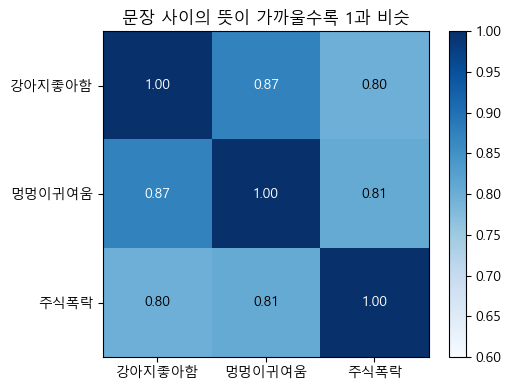

(<matplotlib.colorbar.Colorbar at 0x19da8eea230>, None, None)

In [8]:
import torch.nn.functional as F

def embed(texts, prefix = 'query: ', batch_size = 32):
    vectors = []
    for i in range(0, len(texts), batch_size):
        batch = [prefix + t for t in texts[i:i + batch_size]]
        enc = tok(batch, padding = True, truncation = True, max_length = 512, return_tensors = 'pt').to(DEVICE)
        with torch.no_grad():
            hidden = emb_model(**enc).last_hidden_state
        mask = enc['attention_mask'].unsqueeze(-1).float()
        pooled = (hidden * mask).sum(1) / mask.sum(1)
        vectors.append(F.normalize(pooled, p = 2, dim = 1).cpu())
    return torch.cat(vectors)
test = ['나는 강아지를 정말 좋아해요.',
        '우리 집 멍멍이가 세상에서 제일 귀여워요.',
        '주식 시장이 크게 폭락했습니다.']
vecs = embed(test)
sim = vecs @ vecs.T

fig, ax = plt.subplots(figsize = (5.2, 4))
im = ax.imshow(sim.numpy(), cmap = 'Blues', vmin = 0.6, vmax = 1)
ax.set_xticks(range(3)); ax.set_yticks(range(3))
ax.set_xticklabels(['강아지좋아함', '멍멍이귀여움', '주식폭락'])
ax.set_yticklabels(['강아지좋아함', '멍멍이귀여움', '주식폭락'])
for i in range(3):
    for j in range(3):
        ax.text(j, i, f"{sim[i, j]:.2f}", ha = 'center', va = 'center', color = 'white' if sim[i, j] > 0.85 else 'black')
ax.set_title('문장 사이의 뜻이 가까울수록 1과 비슷')
plt.colorbar(im), plt.tight_layout(), plt.show()

In [9]:
from torchvision import transforms, models

img = Image.open(ASSETS / 'puppy.jpg').convert('RGB')
x = transforms.ToTensor()(img)

weights = models.ResNet18_Weights.DEFAULT
resnet = models.resnet18(weights = weights).eval()
labels = weights.meta['categories']

batch = weights.transforms()(img).unsqueeze(0)

with torch.no_grad():
    logits = resnet(batch)
probs = torch.softmax(logits, dim = 1)[0]
top_p, top_i = probs.topk(5)

for p, i in zip(top_p, top_i):
    print(f"{labels[i]:25s} {p:6.1%}")
entroppy = -(probs * torch.log(probs + 1e-10)).sum()


Labrador retriever         23.9%
Sealyham terrier           18.3%
tennis ball                11.6%
Great Pyrenees             11.6%
golden retriever            7.6%


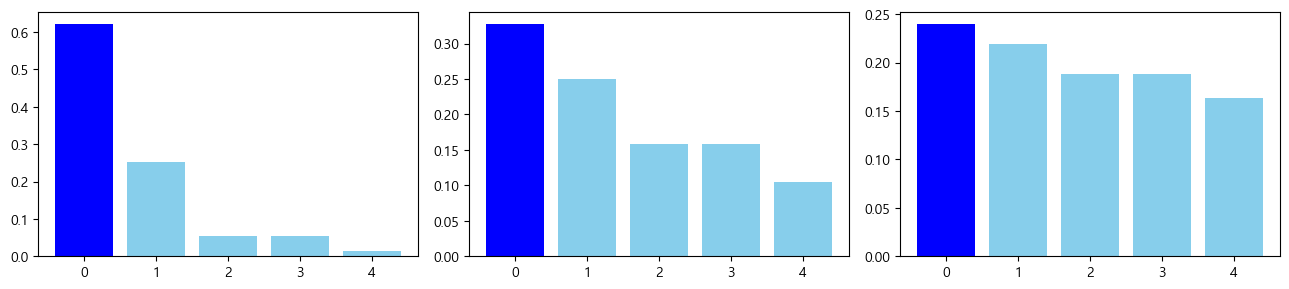

In [10]:
top_logits = logits[0].topk(5).values
fig, axes = plt.subplots(1, 3, figsize = (13, 3), sharex = True)

for ax, T in zip(axes, (0.3, 1.0, 3.0)):
    p = torch.softmax(top_logits / T, dim = 0)
    ax.bar(range(5), p.numpy(), color = ['blue'] + ['skyblue'] * 4)
plt.tight_layout(); plt.show()

In [11]:
from huggingface_hub import HfApi, hf_hub_download, ModelCard

api = HfApi()

try:
    info = api.model_info(EMB_NAME)
    print(info.id)
    print(info.pipeline_tag)
    print(info.downloads)
    print(info.tags)
    for m in api.list_models(filter = 'text-classification', sort = 'downloads', limit = 5):
        print(m.id)
except Exception as e:
    print('Failed', e)

intfloat/multilingual-e5-small
sentence-similarity
11268724
['sentence-transformers', 'pytorch', 'onnx', 'safetensors', 'openvino', 'bert', 'mteb', 'Sentence Transformers', 'sentence-similarity', 'multilingual', 'af', 'am', 'ar', 'as', 'az', 'be', 'bg', 'bn', 'br', 'bs', 'ca', 'cs', 'cy', 'da', 'de', 'el', 'en', 'eo', 'es', 'et', 'eu', 'fa', 'fi', 'fr', 'fy', 'ga', 'gd', 'gl', 'gu', 'ha', 'he', 'hi', 'hr', 'hu', 'hy', 'id', 'is', 'it', 'ja', 'jv', 'ka', 'kk', 'km', 'kn', 'ko', 'ku', 'ky', 'la', 'lo', 'lt', 'lv', 'mg', 'mk', 'ml', 'mn', 'mr', 'ms', 'my', 'ne', 'nl', 'no', 'om', 'or', 'pa', 'pl', 'ps', 'pt', 'ro', 'ru', 'sa', 'sd', 'si', 'sk', 'sl', 'so', 'sq', 'sr', 'su', 'sv', 'sw', 'ta', 'te', 'th', 'tl', 'tr', 'ug', 'uk', 'ur', 'uz', 'vi', 'xh', 'yi', 'zh', 'arxiv:2402.05672', 'arxiv:2108.08787', 'arxiv:2104.08663', 'arxiv:2210.07316', 'license:mit', 'model-index', 'eval-results', 'text-embeddings-inference', 'endpoints_compatible', 'region:us']
cross-encoder/ms-marco-MiniLM-L6-v2
BA

In [12]:
try:
    card = ModelCard.load(EMB_NAME)
    print(card.text[:500].strip())
except Exception as e:
    print('Failed', e)
cfg = json.load(open(hf_hub_download(EMB_NAME, 'config.json')))
for k in ('model_type', 'num_hidden_layers', 'hidden_size', 'num_attention_heads', 'vocab_size', 'max_position_embeddings'):
    print(k, cfg[k])

README.md:   0%|          | 0.00/498k [00:00<?, ?B/s]

c:\Users\use\Documents\KDT17\RAG\.venv\lib\site-packages\huggingface_hub\file_download.py:149: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\use\.cache\huggingface\hub\models--intfloat--multilingual-e5-small. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


## Multilingual-E5-small

[Multilingual E5 Text Embeddings: A Technical Report](https://arxiv.org/pdf/2402.05672).
Liang Wang, Nan Yang, Xiaolong Huang, Linjun Yang, Rangan Majumder, Furu Wei, arXiv 2024

This model has 12 layers and the embedding size is 384.

## Usage

Below is an example to encode queries and passages from the MS-MARCO passage ranking dataset.

```python
import torch.nn.functional as F

from torch import Tensor
from transformers import AutoTokenizer, AutoModel


def average
model_type bert
num_hidden_layers 12
hidden_size 384
num_attention_heads 12
vocab_size 250037
max_position_embeddings 512


In [13]:
from transformers import pipeline, set_seed

en_sentiment = pipeline('sentiment-analysis',
                            model = 'distilbert/distilbert-base-uncased-finetuned-sst-2-english',
                            device = DEVICE)
for s in ['I love working with transformers!', 'This was the worst meeting ever']:
    print(s, en_sentiment(s)[0])

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

c:\Users\use\Documents\KDT17\RAG\.venv\lib\site-packages\huggingface_hub\file_download.py:149: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\use\.cache\huggingface\hub\models--distilbert--distilbert-base-uncased-finetuned-sst-2-english. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
c:\Users\use\Documents\KDT17\RAG\.venv\lib\site-packages\huggingface_hub\

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

I love working with transformers! {'label': 'POSITIVE', 'score': 0.999541163444519}
This was the worst meeting ever {'label': 'NEGATIVE', 'score': 0.999785840511322}


In [14]:
generator = pipeline('text-generation', model = 'gpt2', device = DEVICE)
prompt = 'The future of AI is'

for temp in (0.3, 1.5):
    set_seed(7)
    out = generator(prompt, max_new_tokens = 30,
                    do_sample = True, temperature = temp, top_k = 50)
    print(temp, out[0]['generated_text'])

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

[transformers] Passing `generation_config` together with generation-related arguments=({'top_k', 'do_sample', 'temperature', 'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=30) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer GPT2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.
[transformers] Both `

0.3 The future of AI is not yet clear. But it is possible that AI will be able to solve many problems, and that it will be able to solve many problems at once
1.5 The future of AI is not always on-watch; it's changing how technology is perceived today and, at the end of that era it may just break down into smaller and


In [18]:
from transformers import AutoModelForSequenceClassification

name = 'distilbert/distilbert-base-uncased-finetuned-sst-2-english'
tk = AutoTokenizer.from_pretrained(name)
clf = AutoModelForSequenceClassification.from_pretrained(name).eval()

text = 'Trhe club meeting was surprisingly fun!'
enc = tk(text, return_tensors = 'pt')
with torch.no_grad():
    logits = clf(**enc).logits
probs = torch.softmax(logits, dim = -1)[0]

print(tk.convert_ids_to_tokens(enc['input_ids'][0]))
print(logits[0].numpy().round(2))
print(probs.numpy().round(3))
print(clf.config.id2label, clf.config.id2label[int(probs.argmax())])


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

['[CLS]', 'tr', '##he', 'club', 'meeting', 'was', 'surprisingly', 'fun', '!', '[SEP]']
[-4.23  4.51]
[0. 1.]
{0: 'NEGATIVE', 1: 'POSITIVE'} POSITIVE


In [20]:
bert_tok = AutoTokenizer.from_pretrained('bert-base-uncased')
print(bert_tok.tokenize('Thre ultramarathoner prequalified for the immunohistochemistry conference.'))
for s in ['인공지능비서', '머신러닝', '동아리의해커톤']:
    print(f'다국어 e5 :{s!r:14} ->', tok.tokenize(s))

['th', '##re', 'ultra', '##mara', '##th', '##one', '##r', 'pre', '##qual', '##ified', 'for', 'the', 'im', '##mun', '##oh', '##isto', '##chemist', '##ry', 'conference', '.']
다국어 e5 :'인공지능비서'       -> ['▁인공지능', '비', '서']
다국어 e5 :'머신러닝'         -> ['▁머', '신', '러', '닝']
다국어 e5 :'동아리의해커톤'      -> ['▁동', '아리', '의', '해', '커', '톤']


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

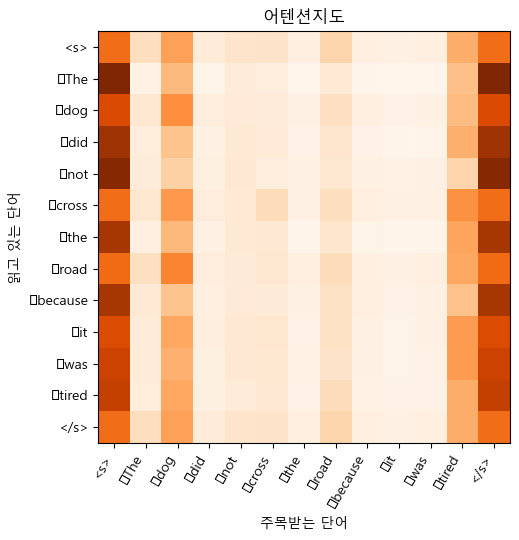

In [21]:
att_model = AutoModel.from_pretrained(EMB_NAME, attn_implementation = 'eager').eval()
sent = 'The dog did not cross the road because it was tired'
enc = tok(sent, return_tensors= 'pt')
with torch.no_grad():
    att = att_model(**enc, output_attentions = True).attentions[-1][0].mean(0)
tokens = tok.convert_ids_to_tokens(enc['input_ids'][0])

fig, ax = plt.subplots(figsize = (6.5, 5.5))
ax.imshow(att.numpy(), cmap = 'Oranges')
ax.set_xticks(range(len(tokens)))
ax.set_xticklabels(tokens, rotation = 60, ha = 'right')
ax.set_yticks(range(len(tokens)))
ax.set_yticklabels(tokens)
ax.set_xlabel('주목받는 단어')
ax.set_ylabel('읽고 있는 단어')
ax.set_title('어텐션지도')
plt.tight_layout()
plt.show()

del att_model
free_memory()

In [23]:
from datasets import load_dataset

nsmc = load_dataset('e9t/nsmc', revision = 'refs/convert/parquet')
print(nsmc)
N_TRAIN, N_EVAL = (3000, 1000) if QUICK else (30000, 5000)
train_raw = nsmc['train'].filter(lambda r: r['document'] is not None and len(r['document']) > 3).shuffle(seed = 42).select(range(N_TRAIN))
eval_raw = nsmc['test'].filter(lambda r: r['document'] is not None and len(r['document']) > 3).shuffle(seed = 42).select(range(N_EVAL))

print(len(train_raw), len(eval_raw))
for r in train_raw.select(range(5)):
    print(f"[{'긍정' if r['label'] else '부정'}] {r['document']}")

default/train/0000.parquet: reconstructing file:   0%|          |  0.00B / 11.1MB            

default/train/0000.parquet: downloading bytes:           |  0.00B            

c:\Users\use\Documents\KDT17\RAG\.venv\lib\site-packages\huggingface_hub\file_download.py:149: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\use\.cache\huggingface\hub\datasets--e9t--nsmc. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


default/test/0000.parquet: reconstructing file:   0%|          |  0.00B / 3.71MB            

default/test/0000.parquet: downloading bytes:           |  0.00B            

...

Generating test split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['id', 'document', 'label'],
        num_rows: 150000
    })
    test: Dataset({
        features: ['id', 'document', 'label'],
        num_rows: 50000
    })
})


Filter:   0%|          | 0/150000 [00:00<?, ? examples/s]

Filter:   0%|          | 0/50000 [00:00<?, ? examples/s]

3000 1000
[부정] 별점 주기도 참~~~~아깝다
[부정] 지루하다..
[부정] OOO기영화 볼것하나없는 최악영화
[긍정] 정말 재밌다....! 기억에 남는 작품..윤시윤...하하...대박이구나...!!!!!!!!!!!!!!
[긍정] 언제봐도 즐거운영화~


In [27]:
from transformers import (AutoModelForSequenceClassification, TrainingArguments, Trainer, DataCollatorWithPadding)

ID2LABEL = {0: '부정', 1: '긍정'}

def tokenize_batch(batch):
    return tok(batch['document'], truncation = True, max_length = 64)

train_ds = train_raw.map(tokenize_batch, batched = True, remove_columns = ['id', 'document'])
eval_ds = eval_raw.map(tokenize_batch, batched = True, remove_columns = ['id', 'document'])

def accuracy(eval_pred):
    logits, y = eval_pred
    return {'accuracy' : float((np.argmax(logits, axis = -1) == y).mean())}

set_seed(42)
ft_model = AutoModelForSequenceClassification.from_pretrained(EMB_NAME, num_labels = 2, id2label = ID2LABEL, label2id = {v: k for k, v in ID2LABEL.items()})
args = TrainingArguments(
    output_dir = str(WORK / 'ckpt'), 
    num_train_epochs = 2 if QUICK else 3,
    per_device_train_batch_size = 32,
    per_device_eval_batch_size = 64,
    learning_rate = 5e-5,
    weight_decay = 0.01,
    eval_strategy = 'epoch',
    save_strategy = 'no',
    logging_steps = 20,
    report_to = 'none',
    seed = 42
    )

trainer = Trainer(model = ft_model, args = args, train_dataset = train_ds, eval_dataset = eval_ds, data_collator = DataCollatorWithPadding(tok),
                            compute_metrics = accuracy)

base_acc = trainer.evaluate()['eval_accuracy']
print(f'파인튜닝 전 정확도: {base_acc:.1%}')



Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: intfloat/multilingual-e5-small
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Training Loss,Validation Loss,Epoch,Accuracy
No log,0.693501,0,0.499000


파인튜닝 전 정확도: 49.9%


In [28]:
t0 = time.time()
trainer.train()
print(f'학습시간{time.time() - t0:0f}초')

ft_acc = trainer.evaluate()['eval_accuracy']
print(f'파인튜닝 후 정확도 : {ft_acc:.1%}')


Epoch,Training Loss,Validation Loss,Accuracy
1,0.507875,0.504557,0.775000
2,0.440180,0.486630,0.786000


학습시간15.991634초


Training Loss,Validation Loss,Epoch,Accuracy
0.440180,0.486630,2,0.786000


파인튜닝 후 정확도 : 78.6%


In [31]:
import torch.nn as nn
class PromptTuningClassifier(nn.Module):
    def __init__(self, model_name, num_virtual_tokens = 20):
        super().__init__()
        self.backbone = AutoModelForSequenceClassification.from_pretrained(
            model_name, num_labels = 2, id2label = ID2LABEL,
            label2id = {v: k for k, v in ID2LABEL.items()})
        self.backbone.requires_grad_(False)
        for p in self.backbone.classifier.parameters():
            p.requires_grad = True
        self.n = num_virtual_tokens
        word_emb = self.backbone.get_input_embeddings()
        init_ids = torch.randint(1000, 2000, (num_virtual_tokens,))
        self.prompt = nn.Parameter(word_emb(init_ids).detach().clone().unsqueeze(0))

    def forward(self, input_ids, attention_mask, labels = None):
        b = input_ids.shape[0]
        word_emb = self.backbone.get_input_embeddings()(input_ids)
        input_embeds = torch.cat([self.prompt.expand(b, -1, -1), word_emb], dim = 1)
        mask = torch.cat([torch.ones(b, self.n, device = attention_mask.device,
                                     dtype = attention_mask.dtype),
                                     attention_mask],
                                     dim = 1)
        return self.backbone(inputs_embeds = input_embeds, attention_mask = mask, labels = labels)
set_seed(42)
pt_model = PromptTuningClassifier(EMB_NAME).to(DEVICE)
n_train = sum(p.numel() for p in pt_model.parameters() if p.requires_grad)
n_total = sum(p.numel() for p in pt_model.parameters())
print('전체 파라미터 : ', n_total)
print('학습 대상 : ', n_train)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: intfloat/multilingual-e5-small
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


전체 파라미터 :  117662210
학습 대상 :  8450


In [33]:
from torch.utils.data import DataLoader

collate = DataCollatorWithPadding(tok)
train_loader = DataLoader(train_ds, batch_size = 32, shuffle = True, collate_fn = collate)
eval_loader = DataLoader(eval_ds, batch_size = 64, collate_fn = collate)

def evaluate_pt(model):
    model.eval()
    correct = 0
    with torch.no_grad():
        for b in eval_loader:
            b = {k: v.to(DEVICE) for k, v in b.items()}
            y = b.pop('labels')
            correct += (model(b['input_ids'], b['attention_mask']).logits.argmax(-1) == y).sum().item()
        return correct / len(eval_ds)
PT_EPOCHS = 4 if QUICK else 8
opt = torch.optim.AdamW([p for p in pt_model.parameters() if p.requires_grad], lr = 2e-2)
pt_losses = []
for epoch in range(PT_EPOCHS):
    pt_model.train()
    total = 0
    for b in train_loader:
        b = {k : v.to(DEVICE) for k, v in b.items()}
        y = b.pop('labels')
        loss = pt_model(b['input_ids'], b['attention_mask'], labels = y).loss
        loss.backward()
        torch.nn.utils.clip_grad_norm_(pt_model.parameters(), 1.0)
        opt.step()
        opt.zero_grad()
        total += loss.item()
    pt_losses.append(total / len(train_loader))
    print(epoch + 1, pt_losses, evaluate_pt(pt_model))
pt_acc = evaluate_pt(pt_model)
print(pt_acc)


1 [0.6690329516187628] 0.711
2 [0.6690329516187628, 0.5648158363839413] 0.711
3 [0.6690329516187628, 0.5648158363839413, 0.5314714442542259] 0.752
4 [0.6690329516187628, 0.5648158363839413, 0.5314714442542259, 0.5060125402313598] 0.746
0.746


In [38]:
import requests

OLLAMA_URL = 'http://localhost:11434'
LLM_MODEL = 'gemma3:4b'
_ollama_proc = None

def ollama_alive():
    try:
        return requests.get(f"{OLLAMA_URL}/api/tags", timeout = 2).ok

    except requests.RequestException:
        return False

def ensure_ollama(model = LLM_MODEL):
    global _ollama_proc

    if not ollama_alive():
        if shutil.which('ollama') is None:
            raise RuntimeError("올라마가 설치되어 있지 않아요.")
        print("올라마 서버를 켜는 중")
        log = open(WORK / 'ollama_server.log', "w")
        _ollama_proc = subprocess.Popen(['ollama', 'serve'], stdout = log, stderr = log, start_new_session = True)

        for _ in range(60):
            if ollama_alive():
                break

            time.sleep(0.5)

        else:
            raise RuntimeError("올라마 서버가 꺼져있어요. log확인")

    have = [m['name'] for m in requests.get(f"{OLLAMA_URL}/api/tags").json().get('models', [])]

    if model not in have and f"{model}:latest" not in have:
        print(f"모델 {model} 다운로드 받는 중 (처음 한번만 오래걸림)")
        last = -1

        with requests.post(f"{OLLAMA_URL}/api/pull", json = {"model": model}, stream = True) as r:
            for line in r.iter_lines():
                if not line:
                    continue

                d = json.loads(line)
                if d.get('total') and d.get('completed'):
                    pct = int(d['completed'] / d['total'] * 100)

                    if pct // 10 != last // 10:
                        print(f"{pct}%", end = " ", flush = True)
                        last = pct

        print("다운로드 완료")
    print(f"서버준비완료 {model}")

ensure_ollama()


서버준비완료 gemma3:4b


In [39]:
def chat(messages, temperature=0.7, model=LLM_MODEL, fmt=None, max_tokens=None, seed=None):
    options = {'temperature': temperature}
    if max_tokens:
        options['num_predict'] = max_tokens
    if seed is not None:
        options['seed'] = seed
    payload = {'model': model, 'messages': messages, 'stream': False, 'options': options, 'keep_alive': '30m'}
    if fmt:
        payload['format'] = fmt
    r = requests.post(f"{OLLAMA_URL}/api/chat", json=payload, timeout=600)
    r.raise_for_status()
    return r.json()['message']['content']

print(chat([{'role': 'user', 'content': '안녕하세요. 당신은 누구입니까? 한 문장으로 말해주세요.'}]))


저는 구글에서 개발한 대규모 언어 모델입니다.


In [40]:
MOA_SYSTEM=("너는 대학 AI입문 동아리, '모아'의 친절한 AI비서 '모아'야."
            "항상 한국어로, 존댓말로, 3문장 이내로 짧게 따뜻하게 대답해줘.")

q="동아리에 처음 왔는데, 너무 떨려요. 어떡하죠?"
print("System 없이:", chat([{'role':'user', 'content':q}],max_tokens=120).strip()[:200].replace('\n',' '))
print("성격 부여후:",chat([{'role':'system','content':MOA_SYSTEM},{'role':'user','content':q}]))

System 없이: 동아리에 처음 오셨다니, 정말 떨리는 마음 충분히 이해해요! 새로운 환경에 대한 기대감과 약간의 긴장감은 당연한 것이니까 너무 걱정하지 마세요.   **1. 떨림 인정하고 편안하게:**  *   **자신을 다독여요:** "처음이라 떨리는 건 당연해. 새로운 시작이기에 설레는 마음을 가지는 게 정상이야." 와 같이 스스로에게 긍정적인 말을 해 주세요. *  
성격 부여후: 안녕하세요, 처음 오시셔서 떨으시는 모습이 정말 멋지십니다! '모아'는 여러분의 AI 입문 여정을 응원하고 돕게 될 거예요. 부담 없이 동아리 활동에 참여하시면서 즐거운 시간을 보내시길 바랍니다. 😊


In [41]:
class MoaChat:
    def __init__(self, system=MOA_SYSTEM, temperature=0.7):
        self.messages = [{'role': 'system',
                          'content': system}]
        self.temperature = temperature

    def say(self, text):
        self.messages.append({'role': 'user',
                              'content': text})
        answer = chat(self.messages, temperature=self.temperature)
        self.messages.append({'role': 'assistant',
                              'content': answer})
        return answer

bot = MoaChat()
print(bot.say('저는 박현주이고, 파이썬을 처음 배워요.'))
print(bot.say('제 이름이 뭐였죠?'))
print(chat([{'role': 'system', 
             'content': MOA_SYSTEM},
            {'role': 'user', 
             'content': '제 이름이 뭐였죠?'}]))

안녕하세요, 박현주님! 파이썬을 처음 배우시는군요. 파이썬은 배우기 쉽고 활용도가 높아 아주 좋은 선택입니다. 모아가 박현주님의 학습 여정을 응원하며, 궁금한 점이 있다면 언제든지 편하게 질문해주세요!
박현주님, 안녕하세요! 박현주님께서 파이썬을 처음 배우시는 멋진 분이시군요. 😊
안녕하세요, 님! 귀하의 이름은 김민지 님으로 기억하고 있습니다. 혹시 다른 이름으로 알고 계신다면 언제든지 말씀해주세요. 😊


In [42]:
import json

def chat_stream(messages, temperature=0.7, model=LLM_MODEL):
    payload = {'model': model,
               'messages': messages,
               'stream': True,
               'options': {'temperature': temperature}}
               
    with requests.post(f"{OLLAMA_URL}/api/chat",
                       json=payload,
                       stream=True,
                       timeout=600) as r:
        for line in r.iter_lines():
            if line:
                chunk = json.loads(line)
                print(chunk['message']['content'], end="", flush=True)

chat_stream([{'role': 'system',
              'content': MOA_SYSTEM},
             {'role': 'user',
              'content': '동아리 마스코트 이름을 지어준다면 어떤 게 좋을까?'}])

안녕하세요, 여러분! '모아'입니다. 동아리 마스코트 이름을 짓는 건 정말 즐거운 고민이네요. 

저는 귀엽고 친근한 느낌의 '모아돌'이나 '모아링'을 추천하고 싶어요. 

혹시 다른 멋진 이름 아이디어가 있으신가요?

In [43]:
review = '해커톤 때 간식을 맛있었는데, 와이파이가 자꾸만 끊겨서 프로젝트 제출을 못할 뻔 했어요. 그래도 팀원들 덕분에 즐거웠습니다.'
sys_json = '후기를 읽고 JSON으로만 답해. 키 : sentiment (긍정/부정/중립), topics(문자열 배열), complaint(불만 한줄, 없으면 빈 문자열)'
raw = chat([{'role' : 'system', 'content' : sys_json}, {'role' : 'user', 'content' : review}], temperature = 0, fmt = 'json')
parsed = json.loads(raw)
print('구조화된 결과 :', json.dumps(parsed, ensure_ascii = False, indent = 2))
print('파이썬에서 바로 사용 :', parsed['sentiment'], parsed['topics'])

구조화된 결과 : {
  "sentiment": "긍정",
  "topics": [
    "간식",
    "와이파이",
    "프로젝트",
    "팀원"
  ],
  "complaint": "와이파이 끊김"
}
파이썬에서 바로 사용 : 긍정 ['간식', '와이파이', '프로젝트', '팀원']


In [48]:
ALL_REVIEWS = [
    '와이파이가 너무 느려서 실습 중간에 계속 멈췄어요.',
    '회장님이 질문마다 끝까지 설명해 줘서 감동받았습니다.',
    '모임 장소가 좁아서 사람이 많은 날은 앉을 자리가 없어요.',
    '마스코트 스티커가 너무 귀여워요! 노트북에 붙였어요'
]

numbered = '\n'.join(f'{i + 1}. {r}' for i, r in enumerate(ALL_REVIEWS))
report = chat ([
    {'role' : 'system' , 'content' : '너는 동아리 운영을 돕는 분석가야. 한국어로 말해줘'},
    {'role' : 'user' , 'content' : f'아래는 동아리 행사 후기 모음이야. 1. 잘한 점 2가지, 2. 개선할 점 3가지를 각각 한줄로 정리해줘. \n\n{numbered}'}  
], temperature = 0.3)
print(report)

## 동아리 행사 후기 분석 결과

**1. 후기 1:**

*   **잘한 점:** 회장님의 꼼꼼한 설명은 참여자들에게 긍정적인 영향을 주었다.
*   **개선할 점:** 와이파이 속도 개선을 통해 실습 진행의 안정성을 확보해야 한다.
*   **개선할 점:** 모임 장소의 용량 확대를 고려해야 한다.

**2. 후기 2:**

*   **잘한 점:** 회장님의 열정적인 자세와 상세한 설명은 동아리 활동의 핵심 요소이다.
*   **개선할 점:** (특정 개선점 없음 - 긍정적인 피드백이므로)
*   **개선할 점:** (특정 개선점 없음 - 긍정적인 피드백이므로)

**3. 후기 3:**

*   **잘한 점:** 동아리 활동의 활성화를 위한 노력은 긍정적이다.
*   **개선할 점:** 모임 장소의 규모를 늘리거나, 대관을 활용하는 방안을 고려해야 한다.
*   **개선할 점:** 다양한 모임 장소 확보를 통해 편의성을 높여야 한다.

**4. 후기 4:**

*   **잘한 점:** 마스코트 스티커를 활용한 홍보 활동은 동아리 정체성을 확립하는 데 기여한다.
*   **개선할 점:** (특정 개선점 없음 - 긍정적인 피드백이므로)
*   **개선할 점:** (특정 개선점 없음 - 긍정적인 피드백이므로)


In [53]:
docs = {p.name: p.read_text(encoding = 'utf-8') for p in sorted(DATA.glob('*.txt'))}
print(list(docs))

['01_동아리소개.txt', '02_학습과정.txt', '03_장비와공간.txt', '04_행사일정.txt', '05_자주묻는질문.txt']


In [55]:
def split_text(text, chunk_size = 300, overlap = 50):
    chunks = []
    for para in [p.strip() for p in text.split('\n\n') if p.strip()]:
        if len(para) <= chunk_size:
            chunks.append(para)
        else:
            start = 0
            while start < len(para):
                chunks.append(para[start:start + chunk_size])
                start += chunk_size - overlap
    return chunks

records = []
for fname, text in docs.items():
    title, _, body = text.partition('\n\n')
    for c in split_text(body):
        records.append({'text': f'[{title.strip()}] {c}', 'source': fname})
print(len(records))
for r in records[:3]:
    print(r['source'], r['text'])



18
01_동아리소개.txt [AI 입문 동아리 '모아' 소개] ## 동아리 목적
'모아'는 전공과 상관없이 누구나 AI를 직접 만져 보며 배우는 대학 연합 학습 동아리입니다. 2024년 3월에 문을 열었고, 현재 회원은 42명입니다. 동아리 슬로건은 "모두 함께 AI 만들기"이며, 코딩 경험이 전혀 없어도 가입할 수 있습니다.
01_동아리소개.txt [AI 입문 동아리 '모아' 소개] ## 정기 모임
정기 모임은 매주 수요일 저녁 7시에 공학관 304호에서 열립니다. 모임 시간은 약 2시간이며, 첫 30분은 간식을 먹으며 근황을 나누는 시간입니다. 수요일이 공휴일이면 같은 시간에 목요일로 옮겨서 진행합니다.
01_동아리소개.txt [AI 입문 동아리 '모아' 소개] ## 회비
회비는 한 학기에 15,000원이며 간식비와 서버 이용료로 사용합니다. 학기 첫 모임 후 2주 안에 총무 박서연에게 계좌이체로 내면 됩니다. 형편이 어려운 회원은 회장에게 말하면 회비를 면제받을 수 있습니다.


In [56]:
import chromadb
from chromadb.config import Settings

chroma = chromadb.PersistentClient(path = str(WORK / 'chroma'),
                                   settings = Settings(anolymized_telemetry = False))
try:
    chromadb.delete_collection('moa_knowledge')
except Exception:
    pass

collection = chroma.create_collection('moa_knowledge', metadata = {'hnsw:space' : 'cosine'})
doc_vecs = embed([r['text'] for r in records], prefix = 'passage :')
collection.add(
    ids = [f'chunk-{i}' for i in range(len(records))],
    documents = [r['text'] for r in records],
    metadatas = [{'source' : r['source']} for r in records],
    embeddings = doc_vecs.numpy().tolist()
)

print('저장완료', collection.count(), doc_vecs.shape[1])


저장완료 18 384


In [61]:
def search(question, k = 3):
    q_vec = embed([question], prefix = 'query: ')
    res = collection.query(query_embeddings = q_vec.numpy().tolist(), n_results = k)
    return [{ 'text': t, 'source' : m['source'], 'similarity' : 1 - d} for t, m, d in zip(res['documents'][0], res['metadatas'][0], res['distances'][0])]
for question in ['동아리 회비는 얼마인가요?', '컴퓨터는 빌려주나요?', '상금이 있는 대회가 있나요?']:
    print(question)
    for hit in search(question, k = 2):
        print('유사도 : ', hit['similarity'])
        print('출처 : ', hit['source'])
        print('답변 : ', hit['text'][:90])

동아리 회비는 얼마인가요?
유사도 :  0.9018359184265137
출처 :  01_동아리소개.txt
답변 :  [AI 입문 동아리 '모아' 소개] ## 회비
회비는 한 학기에 15,000원이며 간식비와 서버 이용료로 사용합니다. 학기 첫 모임 후 2주 안에 총무 박서연에게
유사도 :  0.8521539568901062
출처 :  01_동아리소개.txt
답변 :  [AI 입문 동아리 '모아' 소개] ## 임원진
회장은 김도윤(컴퓨터공학과 3학년), 부회장은 이하은(국어국문학과 2학년), 총무는 박서연(경영학과 3학년)입니다
컴퓨터는 빌려주나요?
유사도 :  0.8352451324462891
출처 :  03_장비와공간.txt
답변 :  [모아 장비와 공간 이용 안내] ## 노트북 대여
동아리에는 대여용 맥북이 5대 있습니다. 한 번에 최대 7일까지 빌릴 수 있고, 연장은 한 번만 가능합니다. 대
유사도 :  0.8056174516677856
출처 :  03_장비와공간.txt
답변 :  [모아 장비와 공간 이용 안내] ## GPU 서버
무거운 이미지 생성이나 학습은 연구실에 있는 GPU 서버 'moa-gpu'를 사용합니다. 서버는 예약제로 운영되
상금이 있는 대회가 있나요?
유사도 :  0.824271559715271
출처 :  05_자주묻는질문.txt
답변 :  [모아 자주 묻는 질문] ## 후기 작성
행사가 끝나면 단체 채팅방에 한 줄 후기를 남겨 주세요. 후기는 다음 행사를 준비하는 데 쓰이며, 후기를 남긴 회원 중 
유사도 :  0.816826343536377
출처 :  04_행사일정.txt
답변 :  [모아 올해 행사 일정] ## 해커톤
올해 해커톤은 11월 15일 토요일에 공학관 대강당에서 열립니다. 참가비는 무료이고, 팀은 3명에서 4명으로 꾸립니다. 1등


In [68]:
RAG_SYSTEM = ("너는 대학 AI 입문 동아리 '모아'의 AI 비서 '모아'야. 반드시 아래 [참고 자료]에 있는 내용만 근거로 한국어 존댓말로 대답해줘. "
              "자료에 답이 없으면 지어내지 말고 '제가 가진 자료에는 없는 내용이에요. 임원진에게 문의해 주세요.'라고 말해")

def ask_moa(question, k=3, temperature=0.1, show_sources=True):
    hits = search(question, k=k)
    context = '\n\n'.join(f"({h['source']}) {h['text']}" for h in hits)
    answer = chat([
        {'role': 'system', 'content': RAG_SYSTEM},
        {'role': 'user', 'content': f'[참고 자료]\n{context}\n\n[질문]\n{question}'}
    ], temperature=temperature)

    if show_sources:
        answer += '\n\n출처: ' + ', '.join(sorted({h['source'] for h in hits}))
    return answer

for q in ['회비는 얼마고 누구한테 내요?', '해커톤 1등 상금이 얼마에요?', '노트북 며칠 빌릴 수 있어요?']:
    print('질문: ', q)
    print('답변: ', ask_moa(q))


질문:  회비는 얼마고 누구한테 내요?
답변:  회비는 한 학기에 15,000원이며, 총무 박서연님께 계좌이체로 2주 안에 내주시면 됩니다.

출처: 01_동아리소개.txt, 05_자주묻는질문.txt
질문:  해커톤 1등 상금이 얼마에요?
답변:  해커톤 1등 팀에게는 도서상품권 30만원이 지급됩니다.

출처: 01_동아리소개.txt, 04_행사일정.txt, 05_자주묻는질문.txt
질문:  노트북 며칠 빌릴 수 있어요?
답변:  안녕하세요, 모아의 AI 비서 모아입니다.

대여용 맥북은 한 번에 최대 7일까지 빌리실 수 있습니다.

출처: 03_장비와공간.txt, 05_자주묻는질문.txt


In [69]:
q = '회장님 나이가 몇 살이에요?'
print('질문 : ', q)
print('답변 : ', ask_moa(q))

질문 :  회장님 나이가 몇 살이에요?
답변 :  회장님 김도윤 님은 컴퓨터공학과 3학년이십니다. 정확한 나이는 제가 가진 자료에는 없지만, 3학년 학생이시라는 정보는 있습니다.

출처: 01_동아리소개.txt, 05_자주묻는질문.txt


In [74]:
from diffusers import StableDiffusionPipeline, StableDiffusionImg2ImgPipeline
from diffusers import StableDiffusionInpaintPipeline, DPMSolverMultistepScheduler

SD_ID = 'stable-diffusion-v1-5/stable-diffusion-v1-5'
SD_INPAINT_ID = 'stable-diffusion-v1-5/stable-diffusion-inpainting'

pipe = StableDiffusionPipeline.from_pretrained(SD_ID, dtype = IMG_DTYPE, variant = 'fp16' if DEVICE == 'cuda' else None, safety_checker = None, requires_safety_checker = False).to(DEVICE)
pipe.scheduler = DPMSolverMultistepScheduler.from_config(pipe.scheduler.config)
pipe.set_progress_bar_config(disable = True)

NEGATIVE = 'low quality, blurry, deformed, ugly, text, watermark'

model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

c:\Users\use\Documents\KDT17\RAG\.venv\lib\site-packages\huggingface_hub\file_download.py:149: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\use\.cache\huggingface\hub\models--stable-diffusion-v1-5--stable-diffusion-v1-5. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 14 files:   0%|          | 0/14 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

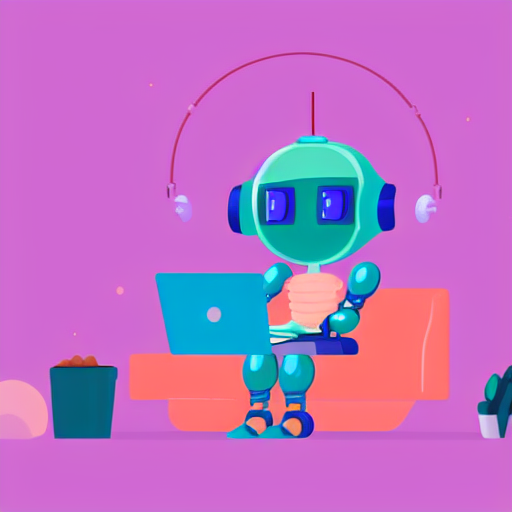

In [79]:
def draw(prompt, negative = NEGATIVE, steps = 20, guidance = 7.5, seed = 0, width = 512, pipeline = None, height = 512, **kw):
    gen = torch.Generator('cpu').manual_seed(seed)
    return (pipeline or pipe)(prompt, negative_prompt = negative, num_inference_steps = steps,
                              guidance_scale = guidance, width = width, height = height,
                              generator = gen, **kw).images[0]
test_img = draw('a cute robot studying with a laptop, flat illustration, pastel colors', seed = 1)
test_img

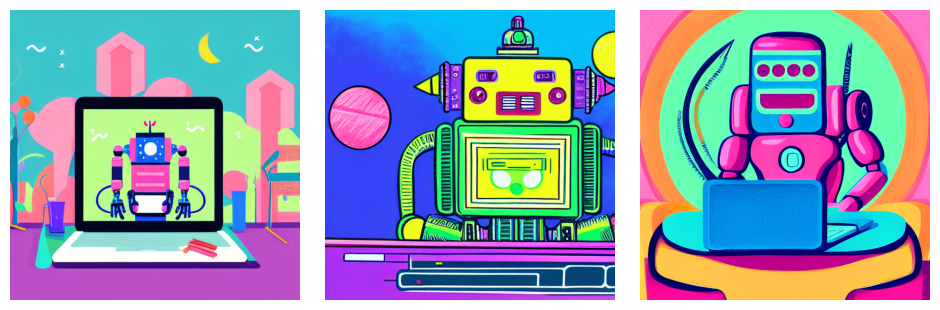

In [83]:
def make_prompt(korean_request):
    return chat([
        {'role': 'system', 'content': "You write prompts for Stable Diffusion, Convert the user's Korean request into ONE English prompt: "
         "comma-seperated keywords, vivid style words, max 35 words. Output only the prompt."},
        {'role': 'user', 'content': korean_request}
    ], temperature = 0.4, max_tokens = 100).strip().strip('"')

request = '동아리 홍보 포스터에 쓸, 노트북으로 공부하는 로봇 일러스트, 파스텔 색감'
en_prompt = make_prompt(request)
show_images([draw(en_prompt, seed = s) for s in (3, 4, 5)])


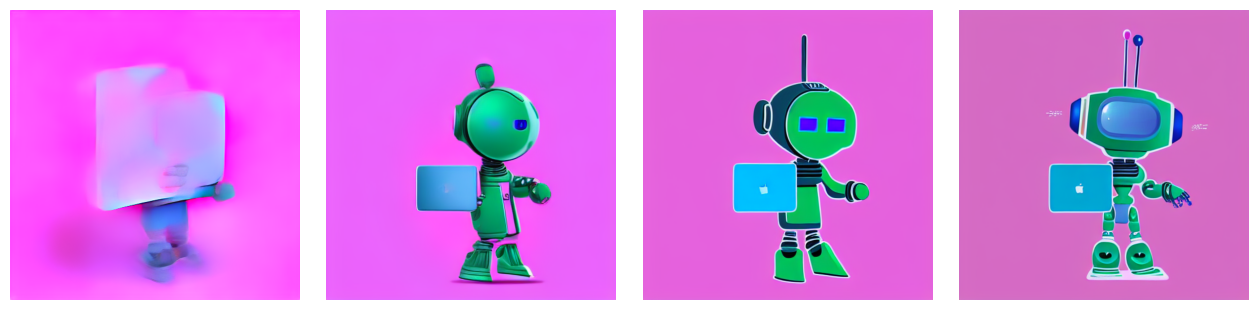

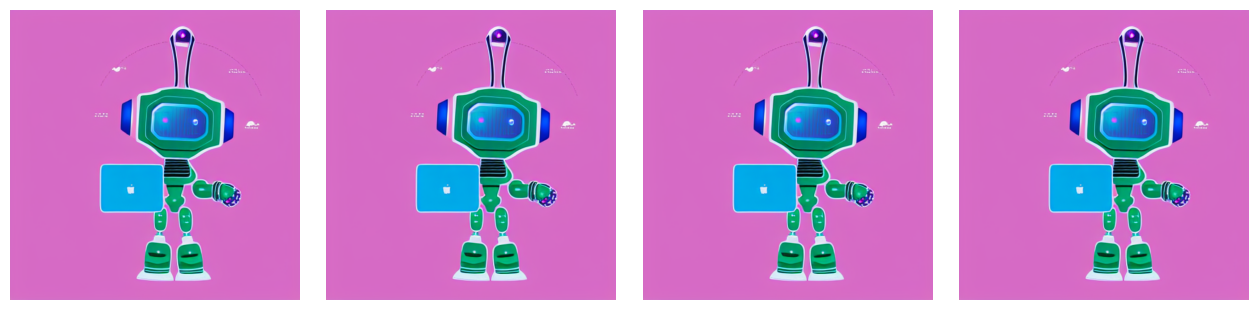

In [84]:
base_prompt = 'a friendly robot mascot holding a laptop, simpl falt illustration, pastel colors'
show_images([draw(base_prompt, steps = s, seed = 1) for s in (2, 5, 10, 25)])
show_images([draw(base_prompt, quidance = g, seed = 1) for g in (1, 4, 7.5, 15)])